# Pitch decay test: effect van heave-demping in `Other damping`

Dit notebook draait twee OrcaFlex-modellen voor dezelfde pitch decay test:

1. **Zonder heave-demping**: alle `OtherDamping...z` termen staan op nul.
2. **Met heave-demping**: alleen de lineaire en/of kwadratische heave-demping in `Other damping` wordt aangepast.

Zo blijft het verschil tussen beide runs zo klein mogelijk en kun je zien of heave-demping invloed heeft op de pitch decay respons.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import OrcFxAPI

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

## 1. Instellingen

Pas hieronder vooral `model_path`, `LINEAR_HEAVE_DAMPING` en `QUADRATIC_HEAVE_DAMPING` aan.

Let op: de eenheden moeten overeenkomen met wat OrcaFlex verwacht voor de `Other damping`-coëfficiënten van jouw objecttype/model.

In [3]:
# Pad naar je OrcaFlex modelbestand
# Gebruik hier hetzelfde basisbestand voor beide simulaties.
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_fixed_120s.dat"

# Namen van objecten in OrcaFlex
FLOATING_OBJECT_NAME = "floaters"
FLOAT_TYPE_NAME = "Floatertype"
CONSTRAINT_NAME = "decay_constraint"  # wordt alleen geladen als hij bestaat

# Startconditie pitch decay
INITIAL_TRIM_DEG = 9.0

# Heave-demping die je wilt testen in model 'met heave damping'
# Vul hier je eigen waarden in.
LINEAR_HEAVE_DAMPING = 4.0       # OtherDampingLinearCoeffz
QUADRATIC_HEAVE_DAMPING = 4.0    # OtherDampingQuadraticCoeffz

# Plot- en analyse-instellingen
PEAK_PROMINENCE = None   # bijvoorbeeld 0.01 als find_peaks te veel pieken vindt
PEAK_DISTANCE = None     # bijvoorbeeld aantal samples tussen pieken

## 2. Helperfuncties

In [4]:
def get_object_if_exists(model, object_name):
    """Geeft OrcaFlex object terug als het bestaat, anders None."""
    try:
        return model[object_name]
    except Exception:
        return None


def set_initial_pitch_decay(floaters, initial_trim_deg=6.0):
    """Zet dezelfde startconditie voor beide modellen."""
    floaters.InitialX = 0.0
    floaters.InitialY = 0.0
    floaters.InitialZ = 0.0
    floaters.InitialHeel = 0.0
    floaters.InitialTrim = initial_trim_deg
    floaters.InitialHeading = 0.0


def set_all_other_damping_to_zero(floatertype):
    """Zet alle lineaire en kwadratische Other damping termen op nul."""
    dofs = ["x", "y", "z", "Rx", "Ry", "Rz"]
    for dof in dofs:
        setattr(floatertype, f"OtherDampingLinearCoeff{dof}", 0.0)
        setattr(floatertype, f"OtherDampingQuadraticCoeff{dof}", 0.0)


def set_heave_other_damping(floatertype, linear_z=0.0, quadratic_z=0.0):
    """Zet alleen de heave Other damping termen."""
    floatertype.OtherDampingLinearCoeffz = linear_z
    floatertype.OtherDampingQuadraticCoeffz = quadratic_z


def build_model(model_path, linear_heave_damping=0.0, quadratic_heave_damping=0.0):
    """Laadt model, zet startconditie en zet gewenste heave-demping."""
    model = OrcFxAPI.Model(model_path)
    floaters = model[FLOATING_OBJECT_NAME]
    floatertype = model[FLOAT_TYPE_NAME]
    constraint = get_object_if_exists(model, CONSTRAINT_NAME)

    set_initial_pitch_decay(floaters, INITIAL_TRIM_DEG)
    set_all_other_damping_to_zero(floatertype)
    set_heave_other_damping(floatertype, linear_heave_damping, quadratic_heave_damping)

    return {
        "model": model,
        "floaters": floaters,
        "floatertype": floatertype,
        "constraint": constraint,
    }


def run_and_extract(case):
    """Run simulatie en haal relevante time histories op."""
    model = case["model"]
    floaters = case["floaters"]

    model.RunSimulation()

    return {
        "time": model.general.TimeHistory("Time"),
        "heave": floaters.TimeHistory("Z"),
        "roll": floaters.TimeHistory("Rotation 1"),
        "pitch": floaters.TimeHistory("Rotation 2"),
    }


def calculate_period(time, signal, prominence=None, distance=None):
    """Bepaalt gemiddelde periode op basis van positieve pieken."""
    peaks, _ = find_peaks(signal, prominence=prominence, distance=distance)
    if len(peaks) < 2:
        return None, peaks
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    return float(np.mean(periods)), peaks


def calculate_log_decrement(signal, peaks):
    """Berekent gemiddelde logaritmische decrement op basis van positieve pieken."""
    if len(peaks) < 2:
        return None

    peak_values = np.asarray(signal)[peaks]
    # Alleen positieve pieken gebruiken om logproblemen te vermijden.
    peak_values = peak_values[peak_values > 0]
    if len(peak_values) < 2:
        return None

    decrements = np.log(peak_values[:-1] / peak_values[1:])
    decrements = decrements[np.isfinite(decrements)]
    if len(decrements) == 0:
        return None
    return float(np.mean(decrements))

## 3. Bouw de twee modellen

- `case_without`: zonder heave-demping.
- `case_with`: met lineaire en/of kwadratische heave-demping.

In [5]:
case_without = build_model(
    model_path,
    linear_heave_damping=0.0,
    quadratic_heave_damping=0.0,
)

case_with = build_model(
    model_path,
    linear_heave_damping=LINEAR_HEAVE_DAMPING,
    quadratic_heave_damping=QUADRATIC_HEAVE_DAMPING,
)

print("Case zonder heave damping:")
print("  Linear z    =", case_without["floatertype"].OtherDampingLinearCoeffz)
print("  Quadratic z =", case_without["floatertype"].OtherDampingQuadraticCoeffz)

print("\nCase met heave damping:")
print("  Linear z    =", case_with["floatertype"].OtherDampingLinearCoeffz)
print("  Quadratic z =", case_with["floatertype"].OtherDampingQuadraticCoeffz)

Case zonder heave damping:
  Linear z    = 0.0
  Quadratic z = 0.0

Case met heave damping:
  Linear z    = 4.0
  Quadratic z = 4.0


## 4. Run simulaties

In [6]:
results_without = run_and_extract(case_without)
results_with = run_and_extract(case_with)

## 5. Vergelijk heave en pitch time histories

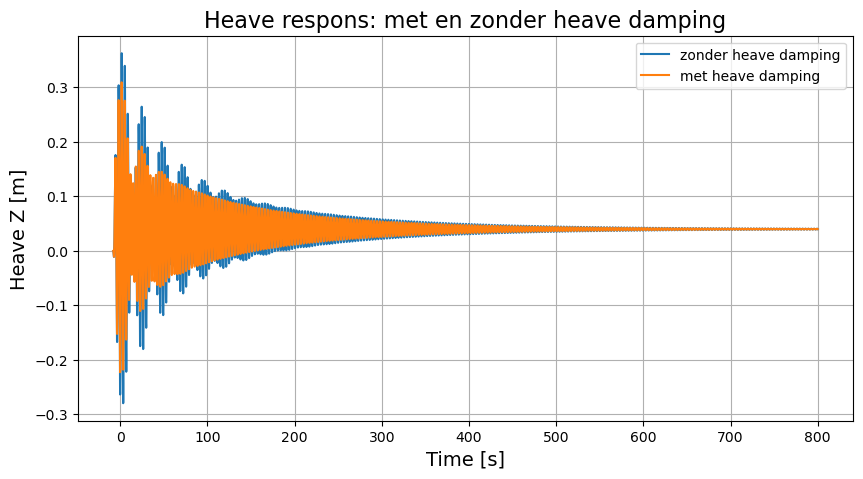

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(results_without["time"], results_without["heave"], label="zonder heave damping")
plt.plot(results_with["time"], results_with["heave"], label="met heave damping")
plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
plt.ylabel("Heave Z [m]", fontsize=LABEL_SIZE)
plt.title("Heave respons: met en zonder heave damping", fontsize=TITLE_SIZE)
plt.grid(True)
plt.legend()
plt.show()

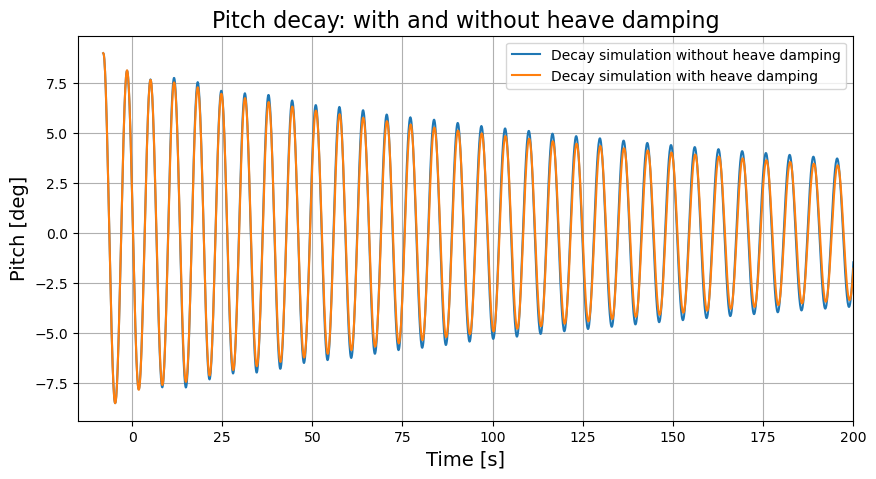

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(results_without["time"], results_without["pitch"], label="Decay simulation without heave damping")
plt.plot(results_with["time"], results_with["pitch"], label="Decay simulation with heave damping")
plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
plt.ylabel("Pitch [deg]", fontsize=LABEL_SIZE)
plt.title("Pitch decay: with and without heave damping", fontsize=TITLE_SIZE)
plt.xlim(-15,200)
plt.grid(True)
plt.legend()
plt.show()

## 6. Verschilplot voor pitch

Deze plot laat direct zien of de pitch respons verandert door heave-demping.

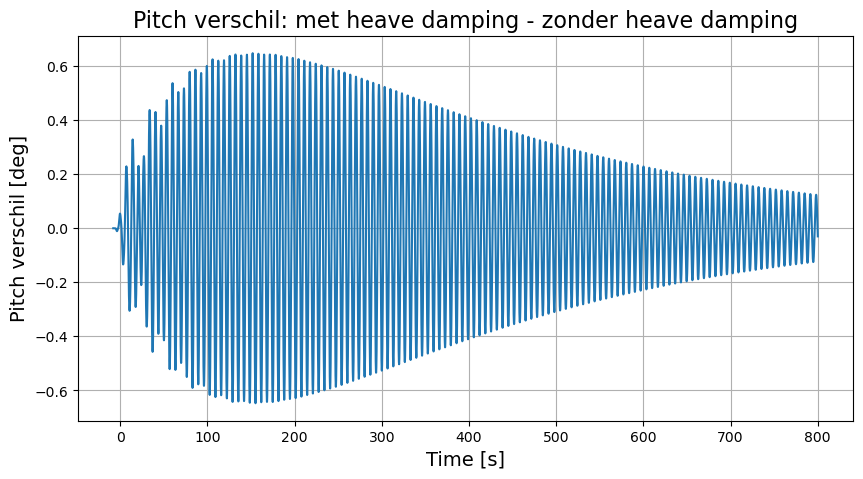

Max abs pitch verschil: 0.647564 deg
RMS pitch verschil:     0.297201 deg


In [9]:
# Interpoleer de case 'met damping' naar de tijdvector van de case 'zonder damping',
# voor het geval de tijdstappen niet exact gelijk zijn.
pitch_with_interp = np.interp(
    results_without["time"],
    results_with["time"],
    results_with["pitch"],
)

pitch_difference = pitch_with_interp - results_without["pitch"]

plt.figure(figsize=(10, 5))
plt.plot(results_without["time"], pitch_difference)
plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
plt.ylabel("Pitch verschil [deg]", fontsize=LABEL_SIZE)
plt.title("Pitch verschil: met heave damping - zonder heave damping", fontsize=TITLE_SIZE)
plt.grid(True)
plt.show()

print(f"Max abs pitch verschil: {np.max(np.abs(pitch_difference)):.6g} deg")
print(f"RMS pitch verschil:     {np.sqrt(np.mean(pitch_difference**2)):.6g} deg")

## 7. Periode en logaritmische decrement van pitch

Hiermee kun je kwantitatief vergelijken of de pitch decay verandert.

In [10]:
T_without, peaks_without = calculate_period(
    results_without["time"],
    results_without["pitch"],
    prominence=PEAK_PROMINENCE,
    distance=PEAK_DISTANCE,
)

T_with, peaks_with = calculate_period(
    results_with["time"],
    results_with["pitch"],
    prominence=PEAK_PROMINENCE,
    distance=PEAK_DISTANCE,
)

logdec_without = calculate_log_decrement(results_without["pitch"], peaks_without)
logdec_with = calculate_log_decrement(results_with["pitch"], peaks_with)

print("--- Resultaten pitch decay ---")
print(f"Aantal positieve pieken zonder heave damping: {len(peaks_without)}")
print(f"Aantal positieve pieken met heave damping:    {len(peaks_with)}")

if T_without is not None:
    print(f"Periode zonder heave damping: {T_without:.3f} s")
else:
    print("Periode zonder heave damping: niet te bepalen")

if T_with is not None:
    print(f"Periode met heave damping:    {T_with:.3f} s")
else:
    print("Periode met heave damping: niet te bepalen")

if T_without is not None and T_with is not None:
    print(f"Verschil periode:             {T_with - T_without:.3f} s")

if logdec_without is not None:
    print(f"Log decrement zonder:         {logdec_without:.6g}")
else:
    print("Log decrement zonder:         niet te bepalen")

if logdec_with is not None:
    print(f"Log decrement met:            {logdec_with:.6g}")
else:
    print("Log decrement met:            niet te bepalen")

if logdec_without is not None and logdec_with is not None:
    print(f"Verschil log decrement:       {logdec_with - logdec_without:.6g}")

--- Resultaten pitch decay ---
Aantal positieve pieken zonder heave damping: 122
Aantal positieve pieken met heave damping:    122
Periode zonder heave damping: 6.588 s
Periode met heave damping:    6.591 s
Verschil periode:             0.002 s
Log decrement zonder:         0.022534
Log decrement met:            0.0235216
Verschil log decrement:       0.000987516


## 8. Controleplot met gevonden pitch-pieken

Gebruik deze plot om te controleren of `find_peaks` de juiste pieken pakt. Als er te veel of te weinig pieken worden gevonden, pas dan `PEAK_PROMINENCE` of `PEAK_DISTANCE` aan bovenin het notebook.

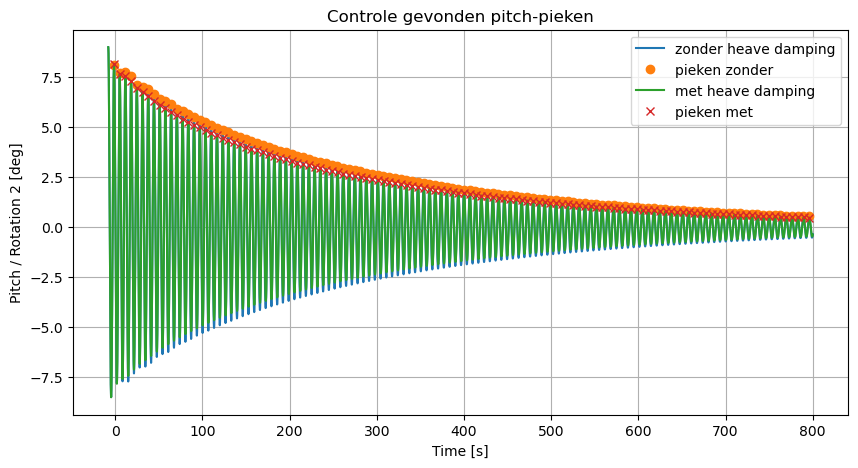

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(results_without["time"], results_without["pitch"], label="zonder heave damping")
plt.plot(
    results_without["time"][peaks_without],
    results_without["pitch"][peaks_without],
    "o",
    label="pieken zonder",
)
plt.plot(results_with["time"], results_with["pitch"], label="met heave damping")
plt.plot(
    results_with["time"][peaks_with],
    results_with["pitch"][peaks_with],
    "x",
    label="pieken met",
)
plt.xlabel("Time [s]")
plt.ylabel("Pitch / Rotation 2 [deg]")
plt.title("Controle gevonden pitch-pieken")
plt.grid(True)
plt.legend()
plt.show()